# Driver Drowsiness Detection — Training Notebook
### Dataset: MRL Eye (talhabhatti7262 · CC0 · Kaggle)
- **~170k eye-crop images** · 2 classes: `Closed (0)` / `Open (1)` · 37 subjects
- Pipeline: Preprocess → Train CNN → Evaluate → Save model

In [1]:
## ── Cell 1: Imports & path setup ────────────────────────────────────────────
import sys, os
sys.path.insert(0, os.path.abspath('..'))   # makes src/ importable

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.21.0
GPU available: []


## Step 1 — Download & extract the MRL Eye dataset

1. Go to: https://www.kaggle.com/datasets/talhabhatti7262/drivers-drowsiness-detection
2. Click **Download** (free Kaggle account required, ~860 MB)
3. Extract so the folder looks like:

```
datasets/raw/mrleye/
├── open/       ← open-eye images   (label 1 = alert)
└── closed/     ← closed-eye images (label 0 = drowsy)
```

Run **Cell 2** below once after placing the dataset.

In [6]:
## ── Cell 2: Preprocess MRL Eye dataset (run ONCE) ───────────────────────────
from src.data.preprocess import MRLEyeProcessor

RAW_DIR       = '../datasets/raw/mrleye'    # contains open/ and closed/
PROCESSED_DIR = '../datasets/processed/mrl_eye'

# Verify expected folder structure exists before processing
for subfolder in ['open', 'closed']:
	folder_path = os.path.join(RAW_DIR, subfolder)
	if not os.path.isdir(folder_path):
		raise FileNotFoundError(
			f"Expected folder not found: {folder_path}\n"
			f"Make sure your structure is:\n"
			f"  {RAW_DIR}/open/   and   {RAW_DIR}/closed/"
		)
	print(f"✓ Found: {folder_path}  ({len(os.listdir(folder_path))} files)")

proc   = MRLEyeProcessor(raw_dir=RAW_DIR, processed_dir=PROCESSED_DIR)
splits = proc.process_and_save(augment_closed=True)
# TIP: limit to 5000 images per class for a quick smoke-test:
# splits = proc.process_and_save(augment_closed=True, max_per_class=5000)

X_train, y_train = splits['X_train'], splits['y_train']
print(f"\nTrain : {X_train.shape}  class counts: {np.bincount(y_train)}")
print(f"Val   : {splits['X_val'].shape}")
print(f"Test  : {splits['X_test'].shape}")

✓ Found: ../datasets/raw/mrleye\open  (42952 files)
✓ Found: ../datasets/raw/mrleye\closed  (41946 files)
Loading MRL Eye dataset from: ..\datasets\raw\mrleye
  closed   (label=0): 41946 images loaded
  open     (label=1): 42952 images loaded
  Total: 84898 images  |  Shape: (84898, 64, 64, 3)
  Saved X_train.npy  (59428, 64, 64, 3)
  Saved y_train.npy  (59428,)
  Saved X_val.npy  (12734, 64, 64, 3)
  Saved y_val.npy  (12734,)
  Saved X_test.npy  (12736, 64, 64, 3)
  Saved y_test.npy  (12736,)

✓ MRL Eye preprocessing complete → ..\datasets\processed\mrl_eye

Train : (59428, 64, 64, 3)  class counts: [29362 30066]
Val   : (12734, 64, 64, 3)
Test  : (12736, 64, 64, 3)


## Step 2 — Explore the dataset

Loaded MRL splits — train:59428  val:12734  test:12736


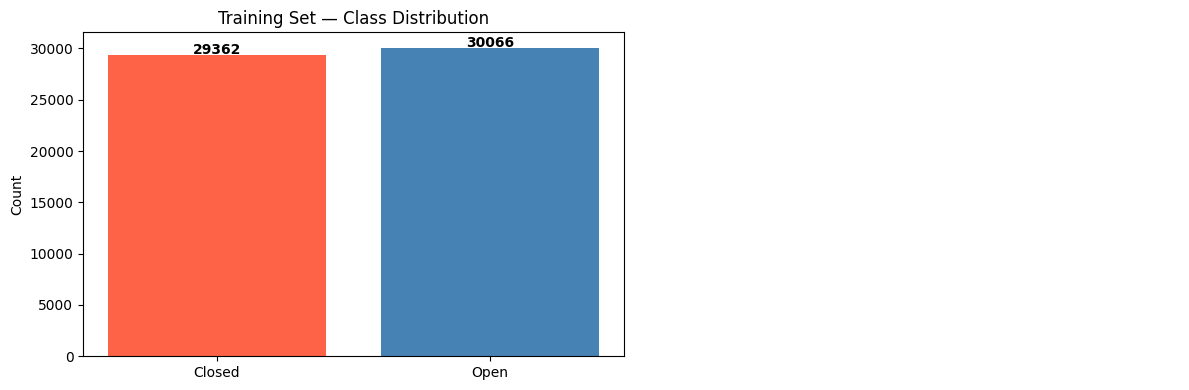

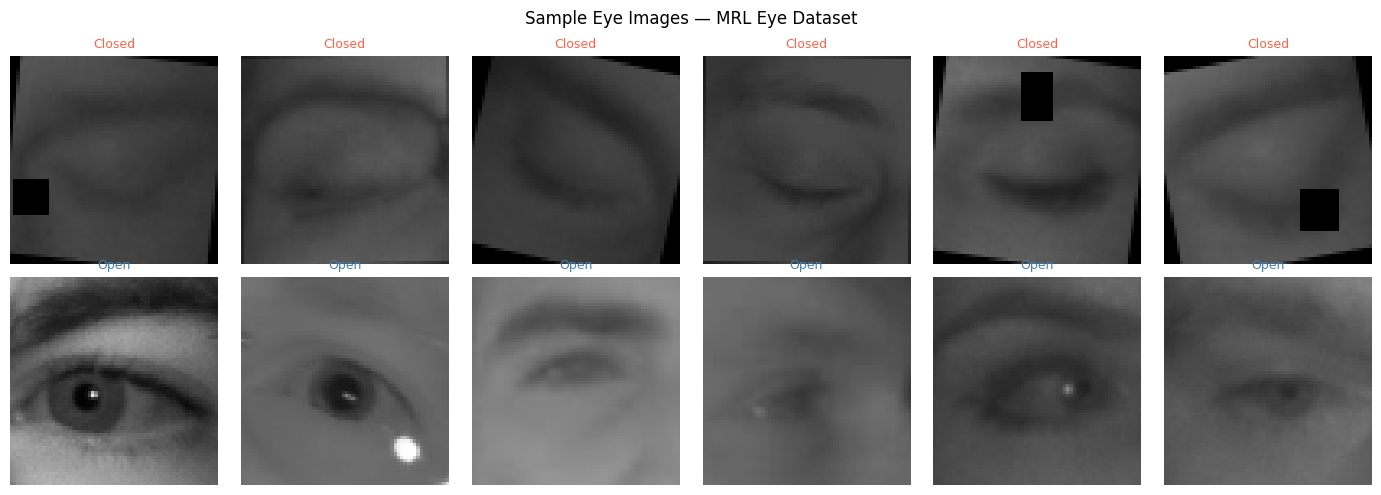

Train: 59428 | Val: 12734 | Test: 12736
Image shape: (64, 64, 3)


In [7]:
## ── Cell 3: EDA — class distribution & sample images ───────────────────────
from src.data.preprocess import MRLEyeProcessor, MRL_CLASS_NAMES

(X_train, y_train), (X_val, y_val), (X_test, y_test) = \
    MRLEyeProcessor.load_processed(PROCESSED_DIR)

# Class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = np.bincount(y_train)
axes[0].bar(MRL_CLASS_NAMES, counts, color=['tomato', 'steelblue'])
axes[0].set_title('Training Set — Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')
axes[1].axis('off')
plt.tight_layout()
plt.show()

# Sample images grid: 2 rows (Closed / Open) × 6 cols
fig2, grid = plt.subplots(2, 6, figsize=(14, 5))
for cls_idx, cls_name in enumerate(MRL_CLASS_NAMES):
    idxs = np.where(y_train == cls_idx)[0][:6]
    for col, idx in enumerate(idxs):
        grid[cls_idx, col].imshow(X_train[idx])
        grid[cls_idx, col].set_title(cls_name, fontsize=9,
                                     color='tomato' if cls_idx == 0 else 'steelblue')
        grid[cls_idx, col].axis('off')
plt.suptitle('Sample Eye Images — MRL Eye Dataset', fontsize=12)
plt.tight_layout()
plt.show()

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")
print(f"Image shape: {X_train[0].shape}")

## Step 3 — Build & train the model

In [13]:
## ── Cell 4: Build model ──────────────────────────────────────────────────────
from src.models.architecture import DrowsinessDetectionModel

MODEL_TYPE  = 'simple_cnn'
NUM_CLASSES = 1          # 1 unit + sigmoid = binary (Closed=0, Open=1)
INPUT_SHAPE = (64, 64, 3)

model_wrapper = DrowsinessDetectionModel(
    MODEL_TYPE, num_classes=NUM_CLASSES, input_shape=INPUT_SHAPE
)
model = model_wrapper.model
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │             

 Total params: 2,622,657 (10.00 MB)

 Trainable params: 2,620,161 (10.00 MB)

 Non-trainable params: 2,496 (9.75 KB)

In [15]:
## ── Cell 5: Train ───────────────────────────────────────────────────────────
from src.data.preprocess import MRLEyeProcessor

BATCH_SIZE = 64
EPOCHS     = 30
CKPT_PATH  = '../models/checkpoints/mrl_eye_best.keras'
LOG_DIR    = '../results/logs/mrl_eye'

os.makedirs('../models/checkpoints', exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

train_ds = MRLEyeProcessor.to_tf_dataset(X_train, y_train, BATCH_SIZE, shuffle=True)
val_ds   = MRLEyeProcessor.to_tf_dataset(X_val,   y_val,   BATCH_SIZE, shuffle=False)

# Binary classification: 1-unit sigmoid + binary_crossentropy
# Precision/Recall are computed via sklearn in Cell 7 — no metrics conflict here
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        CKPT_PATH, monitor='val_accuracy', save_best_only=True, verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=6, restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1
    ),
    tf.keras.callbacks.TensorBoard(log_dir=LOG_DIR),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
)
print("\n✓ Training complete. Best model →", CKPT_PATH)

Epoch 1/30
929/929 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.9675 - loss: 0.0911
Epoch 1: val_accuracy improved from None to 0.99497, saving model to ../models/checkpoints/mrl_eye_best.keras

Epoch 1: finished saving model to ../models/checkpoints/mrl_eye_best.keras
929/929 ━━━━━━━━━━━━━━━━━━━━ 164s 172ms/step - accuracy: 0.9855 - loss: 0.0462 - val_accuracy: 0.9950 - val_loss: 0.0462 - learning_rate: 0.0010
Epoch 2/30
928/929 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.9927 - loss: 0.0240
Epoch 2: val_accuracy did not improve from 0.99497
929/929 ━━━━━━━━━━━━━━━━━━━━ 107s 115ms/step - accuracy: 0.9939 - loss: 0.0209 - val_accuracy: 0.9864 - val_loss: 0.0888 - learning_rate: 0.0010
Epoch 3/30
929/929 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.9936 - loss: 0.0226
Epoch 3: val_accuracy did not improve from 0.99497
929/929 ━━━━━━━━━━━━━━━━━━━━ 85s 91ms/step - accuracy: 0.9943 - loss: 0.0201 - val_accuracy: 0.9943 - val_loss: 0.0164 - learning_rate: 0.0010
Epoch 4/30
929/9

## Step 4 — Evaluate & plot results

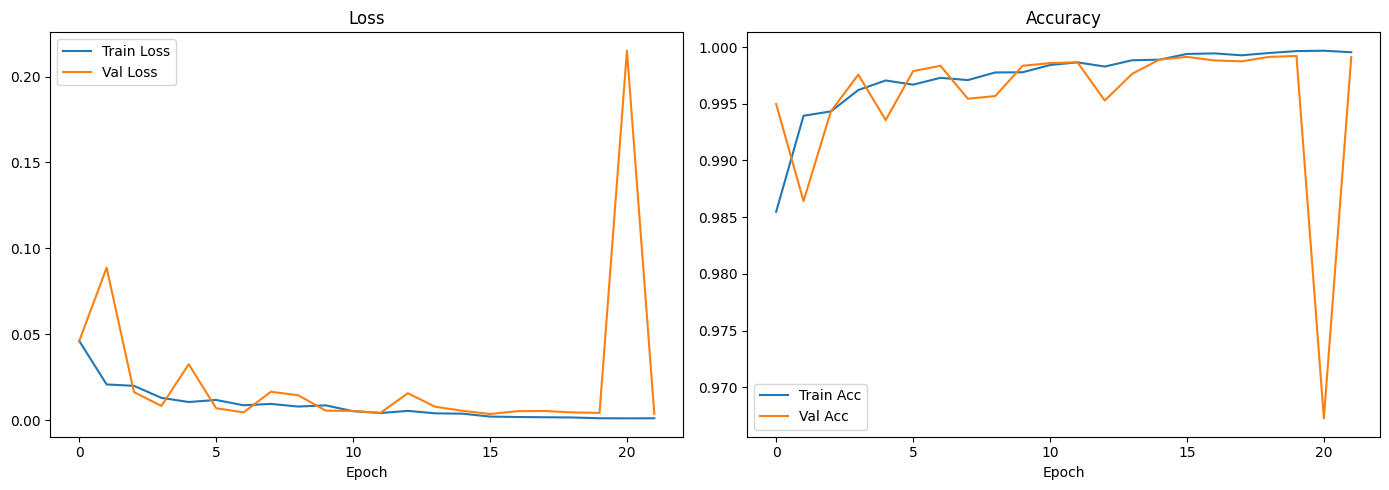

In [16]:
## ── Cell 6: Training curves ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')

axes[1].plot(history.history['accuracy'],     label='Train Acc')
axes[1].plot(history.history['val_accuracy'], label='Val Acc')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].set_xlabel('Epoch')

plt.tight_layout()
plt.savefig('../results/reports/training_curves.png', dpi=150)
plt.show()


  Test Accuracy  : 0.9995
  Precision      : 0.9995
  Recall         : 0.9995
  F1-Score       : 0.9995   (target > 0.85)

Classification Report:
              precision    recall  f1-score   support

      Closed       1.00      1.00      1.00      6292
        Open       1.00      1.00      1.00      6444

    accuracy                           1.00     12736
   macro avg       1.00      1.00      1.00     12736
weighted avg       1.00      1.00      1.00     12736



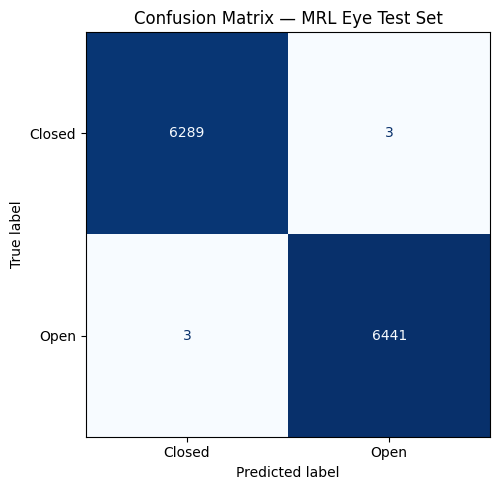

In [17]:
## ── Cell 7: Test-set evaluation + confusion matrix ──────────────────────────
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score
from src.data.preprocess import MRL_CLASS_NAMES

test_ds = MRLEyeProcessor.to_tf_dataset(X_test, y_test, BATCH_SIZE, shuffle=False)

test_loss, test_acc = model.evaluate(test_ds, verbose=0)

# Compute predictions for sklearn metrics
y_pred_probs = model.predict(test_ds, verbose=0)
y_pred = (y_pred_probs.squeeze() > 0.5).astype(int)

test_prec = precision_score(y_test, y_pred)
test_rec  = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print(f"\n{'='*45}")
print(f"  Test Accuracy  : {test_acc:.4f}")
print(f"  Precision      : {test_prec:.4f}")
print(f"  Recall         : {test_rec:.4f}")
print(f"  F1-Score       : {f1:.4f}   (target > 0.85)")
print(f"{'='*45}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=MRL_CLASS_NAMES))

cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=MRL_CLASS_NAMES)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
plt.title('Confusion Matrix — MRL Eye Test Set')
plt.tight_layout()
os.makedirs('../results/reports', exist_ok=True)
plt.savefig('../results/reports/confusion_matrix_mrl.png', dpi=150)
plt.show()


## Step 5 — Save & export model

In [22]:
## ── Cell 8: Save model in multiple formats ──────────────────────────────────
import keras


EXPORT_DIR = '../models/exports'
os.makedirs(EXPORT_DIR, exist_ok=True)

# Keras .h5
h5_path = f'{EXPORT_DIR}/mrl_eye_{MODEL_TYPE}.h5'
model.save(h5_path)
print(f"✓ Keras model     → {h5_path}")

# TF SavedModel
saved_model_path = f'{EXPORT_DIR}/mrl_eye_{MODEL_TYPE}_savedmodel'
keras.saving.save_model(model,saved_model_path)
print(f"✓ TF SavedModel   → {saved_model_path}")

# TFLite (quantized — for Jetson / mobile deployment)
converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_path)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()
tflite_path  = f'{EXPORT_DIR}/mrl_eye_{MODEL_TYPE}.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)
size_kb = os.path.getsize(tflite_path) / 1024
print(f"✓ TFLite model    → {tflite_path}  ({size_kb:.1f} KB)")

✓ Keras model     → ../models/exports/mrl_eye_simple_cnn.h5


ValueError: Invalid filepath extension for saving. Please add either a `.keras` extension for the native Keras format (recommended) or a `.h5` extension. Use `model.export(filepath)` if you want to export a SavedModel for use with TFLite/TFServing/etc. Received: filepath=../models/exports/mrl_eye_simple_cnn_savedmodel.